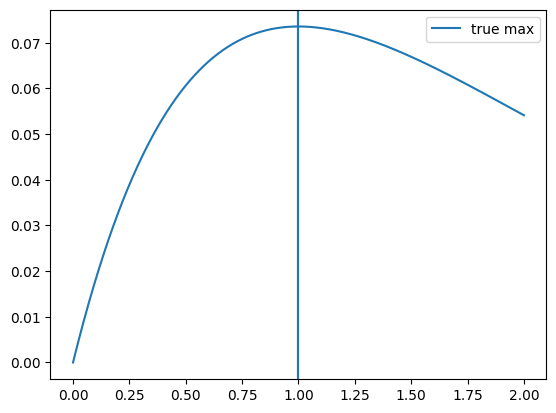

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_54133/1536700562.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/(np.exp(beta*omega)-1)


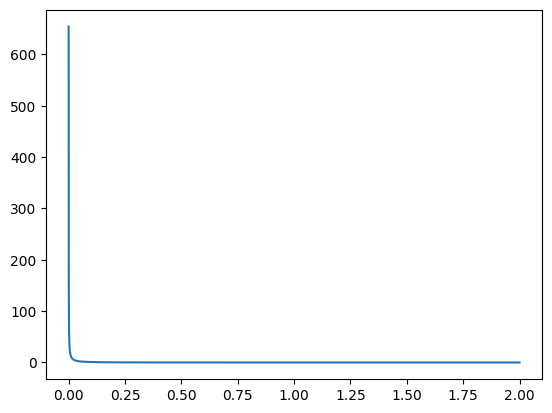

[1.00010001]
1


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_54133/1536700562.py:34: RuntimeWarning: invalid value encountered in scalar multiply
  mult=bose_vals=[spectral_density(omega,zeta)*bose_einstein(omega,0.131)*omega for omega in omegas]


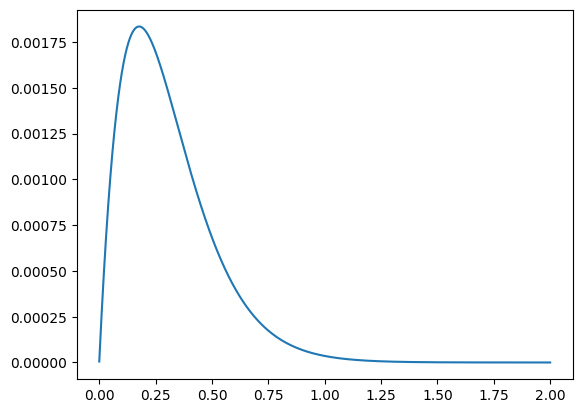

In [1]:
# looking at behaviour of spectral densities and rates for different T
import numpy as np
import matplotlib.pyplot as plt

alpha=0.1
omega_c=1
zeta=1

def spectral_density(omega,zeta):
    return 2*alpha*(omega/omega_c)**zeta *omega_c * np.exp(-omega/omega_c)

omegas=np.linspace(0,2*zeta*omega_c,10000)

density_vals=[spectral_density(omega,zeta) for omega in omegas]
maximum_j = max(density_vals)
pos_max= np.where(density_vals==maximum_j)

plt.plot(omegas,density_vals)
plt.axvline(omegas[pos_max],label='true max')
plt.axvline(zeta*omega_c)
plt.legend()
plt.show()

def bose_einstein(omega,T):
    beta=1/T
    return 1/(np.exp(beta*omega)-1)

bose_vals=[bose_einstein(omega,0.131) for omega in omegas]
plt.plot(omegas,bose_vals)
plt.show()

temperature=0.131

mult=bose_vals=[spectral_density(omega,zeta)*bose_einstein(omega,0.131)*omega for omega in omegas]

plt.plot(omegas,mult)
print(omegas[pos_max])
print(zeta*omega_c)

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_54133/1536700562.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/(np.exp(beta*omega)-1)
/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_54133/4143049691.py:3: RuntimeWarning: invalid value encountered in scalar multiply
  return 2*np.pi * alpha * (1+bose_einstein(omega_a,T)) * spectral_density(omega_a,zeta)
/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_54133/4143049691.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  return 2*np.pi * alpha * bose_einstein(omega_a,T) * spectral_density(omega_a,zeta)


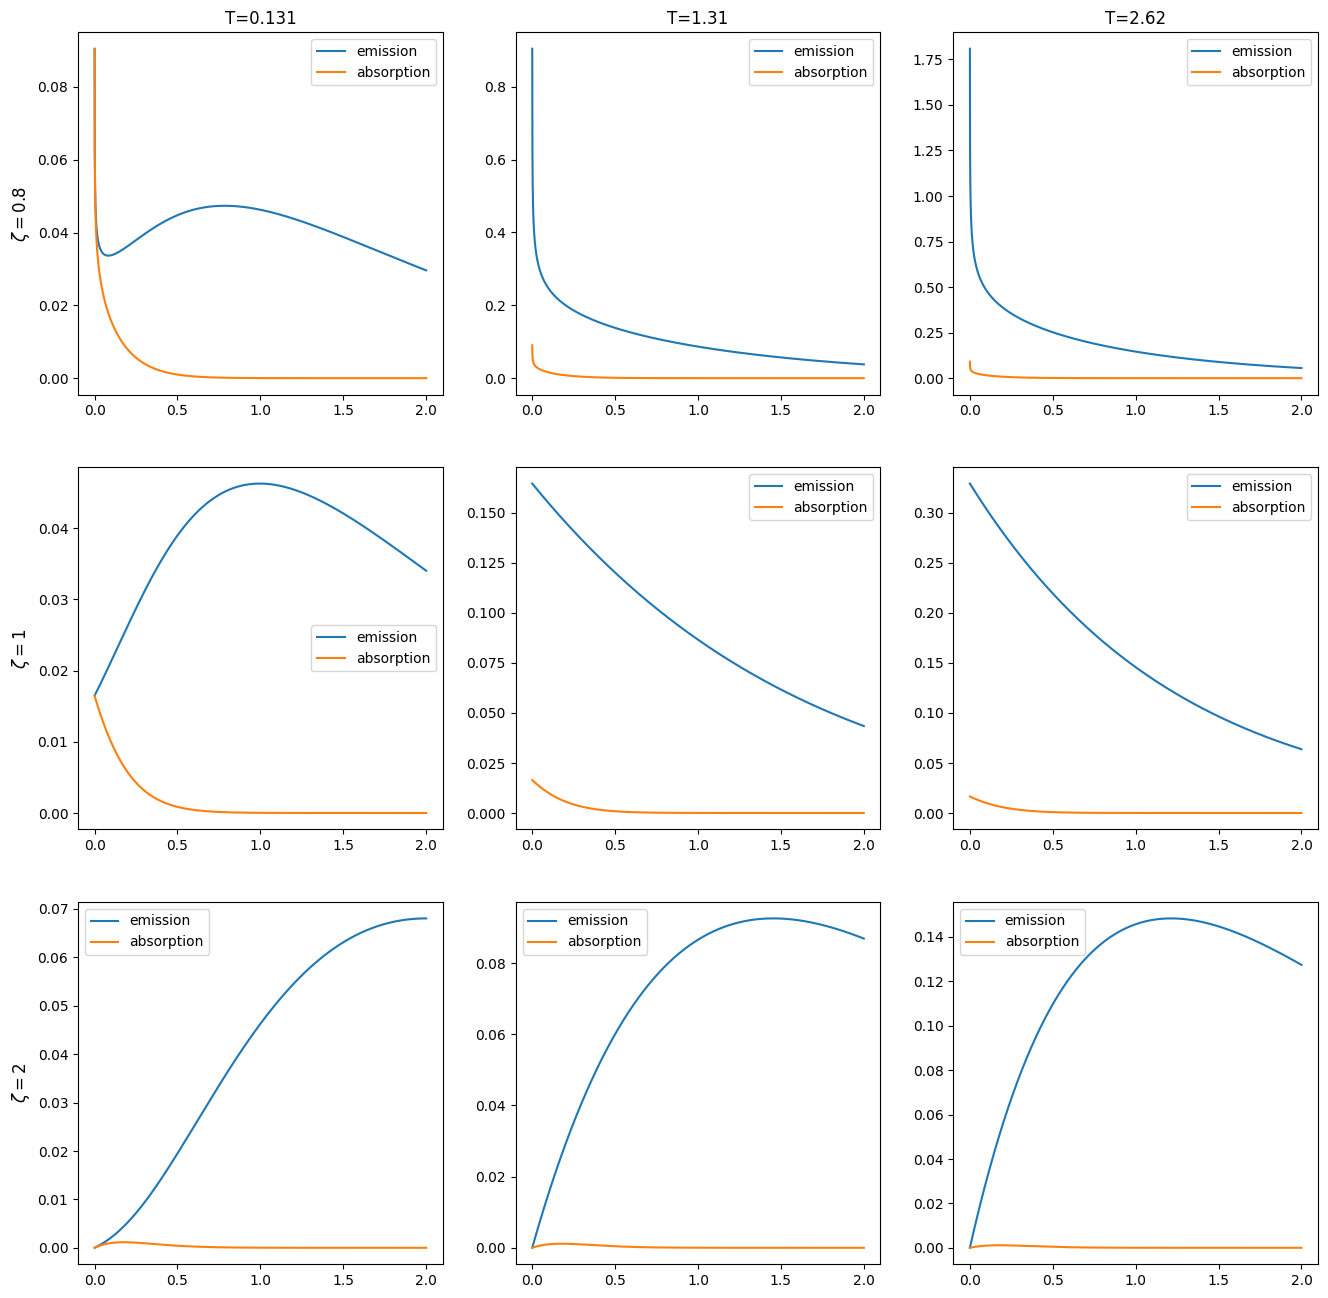

In [2]:
def emission_rate(omega,T,zeta):
    omega_a=abs(omega)
    return 2*np.pi * alpha * (1+bose_einstein(omega_a,T)) * spectral_density(omega_a,zeta)

def absorption_rate(omega,T,zeta):
    omega_a=abs(omega)
    return 2*np.pi * alpha * bose_einstein(omega_a,T) * spectral_density(omega_a,zeta)

zeta_vals=[0.8,1,2]
temperatures=[n*0.131 for n in [1,10,20]]

cols = ['T={}'.format(col) for col in temperatures]
rows = ['$\zeta={}$'.format(row) for row in zeta_vals]

fig,axs=plt.subplots(nrows=3,ncols=3,figsize=(16,16))


for i,zeta in enumerate(zeta_vals):
    for j,temp in enumerate(temperatures):
        rates_e=[emission_rate(omega,temp,zeta) for omega in omegas]
        rates_a = [absorption_rate(omega,0.131,zeta) for omega in omegas]

        axs[i,j].plot(omegas,rates_e,label='emission')
        axs[i,j].plot(omegas,rates_a,label='absorption')
        axs[i,j].legend()

for ax, col in zip(axs[0], cols):
    ax.set_title(col)

for ax, row in zip(axs[:,0], rows):
    ax.set_ylabel(row, rotation=90, size='large')
    
plt.legend()
plt.show()

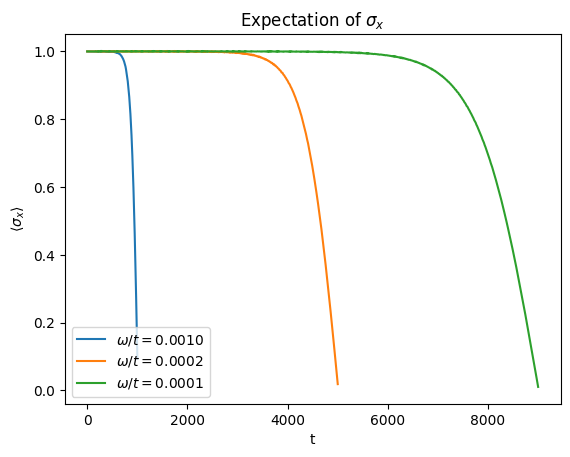

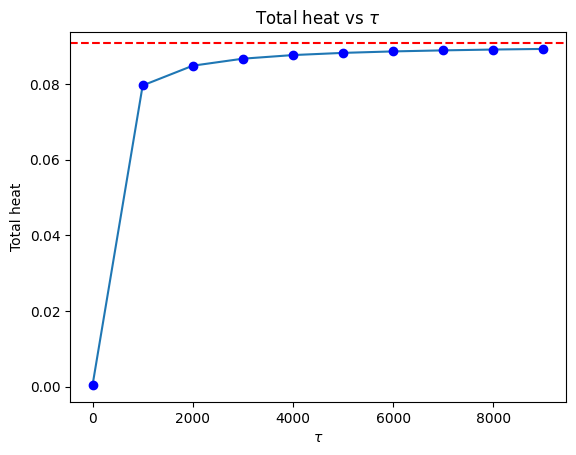

0.08928259653447512


In [11]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


sx = np.array([[0, 1], [1, 0]]) / 2
sy = np.array([[0, -1j], [1j, 0]]) / 2
sz = np.array([[1, 0], [0, -1]]) / 2

xplus = 0.5 * np.array([[1, 1], [1, 1]])   
xminus = 0.5 * np.array([[1, -1], [-1, 1]]) 

alpha = 0.1
omegacut = 1
T = 0.1309

def J(omega):
    return 2 * alpha * omega * np.exp(-omega / omegacut)

def n(omega):
    return 1 / (np.exp(omega / (T)) - 1)

def omega_t(t, omega0):
    return 2*(1 - omega0 * t) + 1e-8

def Hdot(t, omega0):
    return -omega_t(t, omega0) * sx 

def gammaA(t, omega0):
    w = omega_t(t, omega0)
    w=abs(w)
    return 2 * np.pi * J(w) * n(w)

def gammaE(t, omega0):
    w = omega_t(t, omega0)
    w=abs(w)
    return 2 * np.pi * J(w) * (n(w) + 1)

rplus = -0.5 * (sz + 2 * sz @ sx)
rminus = -0.5 * (sz - 2 * sz @ sx)
#rz = -sx

# Lindblad RHS
def lindblad_rhs(t, rho_flat, omega0):
    rho = rho_flat.reshape(2, 2)
    drho = (-0.5 * gammaA(t, omega0) * (rminus @ rplus @ rho + rho @ rminus @ rplus - 2 * rplus @ rho @ rminus)
            -0.5 * gammaE(t, omega0) * (rplus @ rminus @ rho + rho @ rplus @ rminus - 2 * rminus @ rho @ rplus)
            -1j * (Hdot(t, omega0) @ rho - rho @ Hdot(t, omega0)))
    return drho.flatten()

# Omega values (inverse)
invomegas = np.arange(1, 10000, 1000)
omegas = 1 / invomegas
# omega0 is 1/tau

solutions = []
for omega0 in omegas:
    tmax = 1 / omega0
    sol = solve_ivp(lindblad_rhs, [0, tmax], xplus.flatten(), args=(omega0,), t_eval=np.linspace(0, tmax, 600))
    solutions.append(sol) 

plot_indexes=[1,len(solutions)//2,-1]
plot_solutions = [ solutions[i] for i in plot_indexes]
for i, sol in enumerate(plot_solutions):
    rho_t = sol.y.T.reshape(-1, 2, 2)
    sx_expect = [np.trace(r @ sx*2).real for r in rho_t]
    plt.plot(sol.t, sx_expect, label=f"$ \omega/t = {omegas[plot_indexes[i]]:.4f}$")

plt.xlabel("t")
plt.ylabel(r"$\langle \sigma_x \rangle$")
plt.title(r"Expectation of $\sigma_x$")
plt.legend()
plt.show()

# Compute heat currents
heats = []
for i, sol in enumerate(solutions):
    rho_t = sol.y.T.reshape(-1, 2, 2)
    drho_dt = np.gradient(rho_t, axis=0) / np.gradient(sol.t)[:, None, None]
    omega0 = omegas[i]
    integrand = [-np.trace(d @ sx * omega_t(t, omega0)).real for d, t in zip(drho_dt, sol.t)]
    total_heat = np.trapz(integrand, sol.t)
    heats.append(total_heat)

plt.plot(1/omegas, heats)
plt.plot(1/omegas, heats,'bo')
plt.axhline(y=T*np.log(2), color='r', linestyle='--')
plt.xlabel(r"$\tau$")
plt.ylabel(r"Total heat")
plt.title(r"Total heat vs $\tau$")
plt.show()
print(heats[-1])

In [4]:
# now for comparison with tempo
f_time=20

sol_500 = solve_ivp(lindblad_rhs, [0, f_time], xplus.flatten(), args=(1/f_time,), t_eval=np.linspace(0, f_time, 5000)) 
rho_t = sol_500.y.T.reshape(-1, 2, 2)
sx_500 = [np.trace(r @ sx*2).real for r in rho_t]

# heat comparison
drho_dt = np.gradient(rho_t, axis=0) / np.gradient(sol_500.t)[:, None, None]
omega0 = 1/f_time
instant_heat = [-np.trace(d @ sx * omega_t(t, omega0)).real for d, t in zip(drho_dt, sol_500.t)]

# cumulative heat at each time step
heat_500 = np.cumsum(instant_heat * np.gradient(sol_500.t))


0.019176607673718083


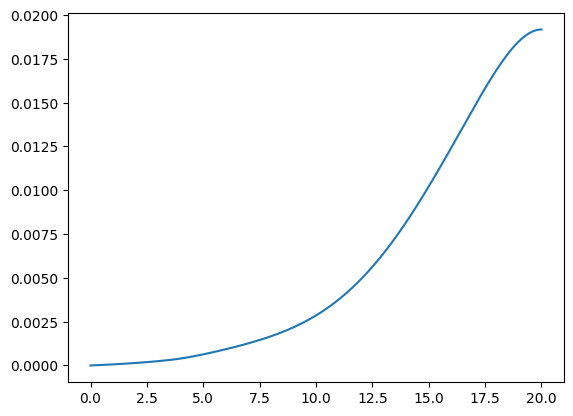

In [5]:
plt.plot(sol_500.t, heat_500)
print(heat_500[-1])

dict_keys(['result', 'log', 'fidelitygrad', 'opttime', 'parameters', 'bounds', 'gtol'])


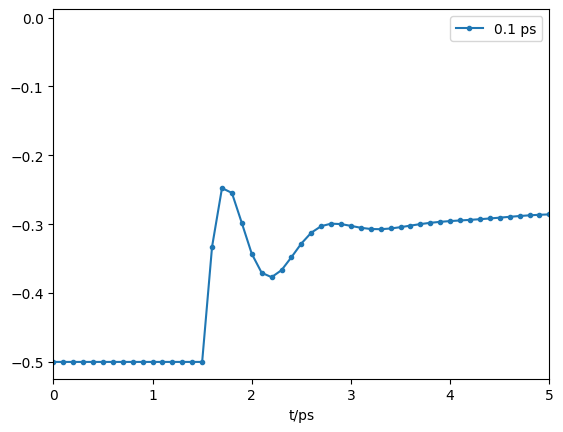

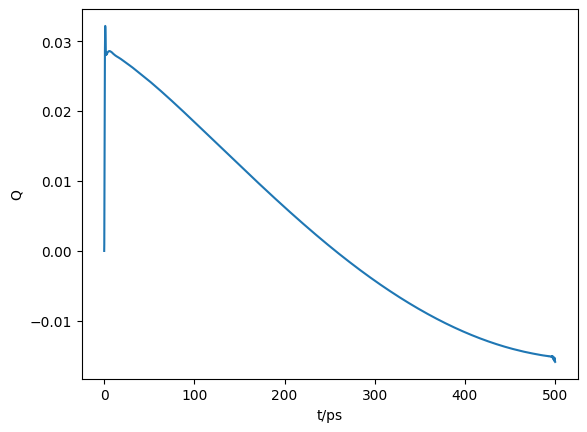

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


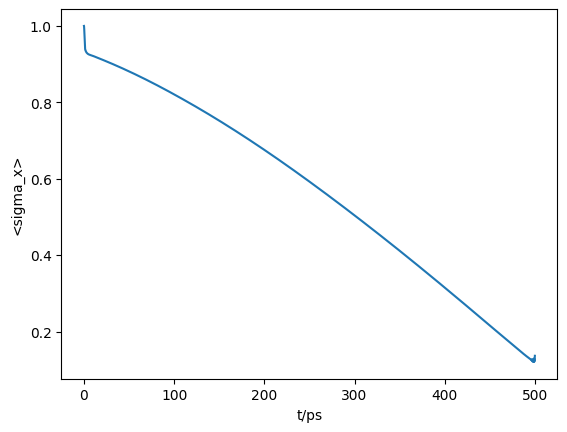

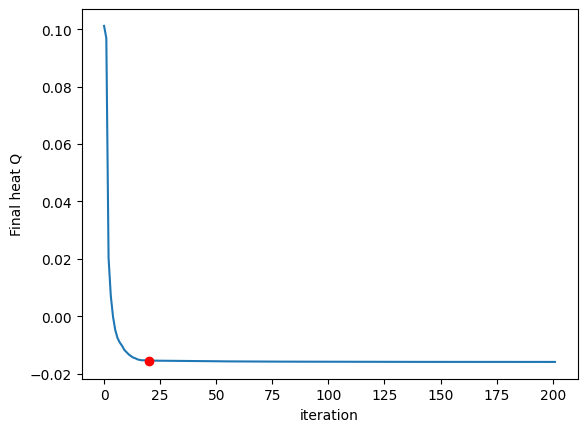

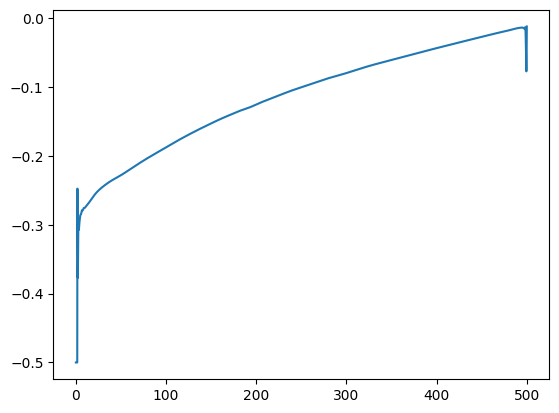

In [6]:
import dill
import matplotlib.pyplot as plt
import numpy as np
import oqupy.operators as op

for dt in [0.1]:
    with open('results/zero_control/conv_checks/dt={0}_ps=-8.0_tcut=500_x=0.5_y=0.0_z=0.0/500ps'.format(dt), 'rb') as f:
        opt_dict = dill.load(f)
    print(opt_dict.keys())

    hx = opt_dict['result'].x[0::3]
    #hy = opt_dict['result'].x[1::3]
    #hz = opt_dict['result'].x[2::3]
    hx = opt_dict['log'][20]['x'][:,0::3][0::2]

    t_prot = 500
    num_steps = len(hx)
    times=np.linspace(0,t_prot,num_steps+1)
    tti_heats=opt_dict['log'][-1]['full heats']
    dynamics=opt_dict['fidelitygrad']['dynamics']

    plt.plot(times[:-1],hx,label='{0} ps'.format(dt),marker='.')
    #plt.plot(times[:-1],hy,label='hy')
    #plt.plot(times[:-1],hz,label='hz')
plt.xlim(0,5)
plt.xlabel('t/ps')
plt.legend()
plt.show()

plt.plot(times,tti_heats)
#plt.xlim(0,50)
plt.xlabel('t/ps')
plt.ylabel('Q')
plt.show()
tti_sx=[np.trace(states@op.sigma("x")) for states in dynamics.states]
plt.plot(times,tti_sx)
plt.xlabel('t/ps')
plt.ylabel('<sigma_x>')
plt.show()

current_iteration=20
num_its=np.shape(opt_dict['log'])[0]
fin_heats=[entry['full heats'][-1] for entry in opt_dict['log']]
plt.plot(range(num_its),fin_heats)
plt.plot(current_iteration,fin_heats[current_iteration],'ro')
plt.xlabel('iteration')
plt.ylabel('Final heat Q')
plt.show()


plt.plot(times[:-1],hx)
plt.show()

In [7]:
import dill
process_tensor_file='results/processtensors/processtensor_dt=0.1_ps=-8.0_tcut=500'
with open(process_tensor_file, 'rb') as f:
    pt_test = dill.load(f)

process_tensor_10K_file='results/processtensors_10K/processtensor_dt=0.2_ps=-6.0_tcut=500'
with open(process_tensor_10K_file, 'rb') as f:
    pt_10K_test = dill.load(f)

--> Compute dynamics:
 54.0%   27 of   50 [#####################-------------------] 00:00:00

100.0%   50 of   50 [########################################] 00:00:01
Elapsed time: 1.7s
Dynamics shape: [2 2]


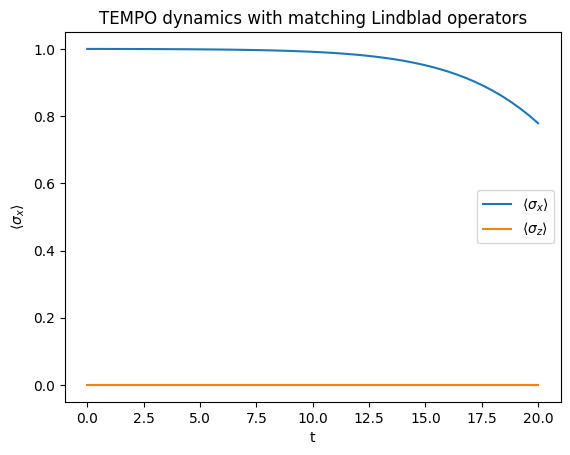

In [ ]:
import numpy as np
from scipy.linalg import expm
from oqupy import TimeDependentSystem, compute_dynamics
from oqupy.process_tensor import SimpleProcessTensor
from oqupy import operators as opr
import oqupy

hs_dim = 2
f_time = 20
num_steps =50
dt = f_time / num_steps

def dissipator_only(L_ops, rates, dim):
    D = np.zeros((dim*dim, dim*dim), dtype=complex)

    for gamma,op in zip(rates,L_ops):
        op_dagger = op.conjugate().T
        D += gamma * (opr.left_right_super(op, op_dagger) \
                                - 0.5 * opr.acommutator(np.dot(op_dagger, op)))
    return D

def tilted_dissipator(L_ops, rates, omegas, u, dim):
    D = np.zeros((dim*dim, dim*dim), dtype=complex)
    I = np.eye(dim)

    for L, gamma, omega in zip(L_ops, rates, omegas):
        Ld = L.conjugate().T

        # jump term (tilted)
        D += gamma * np.exp(u * omega) * opr.left_right_super(L, Ld)

        # anti-commutator (UNTILTED)
        D += -0.5 * gamma * opr.acommutator(Ld @ L)

    return D

pt = SimpleProcessTensor(hilbert_space_dimension=hs_dim, dt=dt)
pt_cf = SimpleProcessTensor(hilbert_space_dimension=hs_dim, dt=dt)
cap = np.array([1.0])

for k in range(num_steps):
    t = (k) * dt
    rates = [gammaA(t,1/f_time), gammaE(t,1/f_time)]

    D = dissipator_only([rplus,rminus], rates, hs_dim)
    E = expm(dt * D) 

    W = np.zeros((1,1,hs_dim*hs_dim, hs_dim*hs_dim), dtype=complex)
    W[0,0,:,:] = E.T # transpose due to tensornetwork conventions ....

    pt.set_mpo_tensor(k, W)
    pt.set_cap_tensor(k, cap)

pt.set_cap_tensor(num_steps, cap)

u=0.01 #counting field

for k in range(num_steps):
    t = (k) * dt
    rates = [gammaA(t,1/f_time), gammaE(t,1/f_time)]

    D = tilted_dissipator(
    [rplus, rminus],
    rates,
    [+omega_t(t,1/f_time), -omega_t(t,1/f_time)],
    u,
    hs_dim
    )

    E = expm(dt * D) 

    W = np.zeros((1,1,hs_dim*hs_dim, hs_dim*hs_dim), dtype=complex)
    W[0,0,:,:] = E.T # transpose due to tensornetwork conventions ....

    pt_cf.set_mpo_tensor(k, W)
    pt_cf.set_cap_tensor(k, cap)


pt_cf.set_cap_tensor(num_steps, cap)


def Hdot_vec(t):
    return Hdot(t,1/f_time)

system = TimeDependentSystem(Hdot_vec)

dynamics = compute_dynamics(
    system=system,
    process_tensor=pt,
    initial_state=oqupy.operators.spin_dm("x+"),
    num_steps=num_steps
)

print("Dynamics shape:", dynamics.shape)

sx_expect = [np.trace(r @ sx*2).real for r in dynamics.states]
sz_expect = [np.trace(r @ sz*2).real for r in dynamics.states]

plt.plot(np.linspace(0, f_time, num_steps+1), sx_expect,label=r"$\langle \sigma_x \rangle$")
plt.plot(np.linspace(0, f_time, num_steps+1), sz_expect,label=r"$\langle \sigma_z \rangle$")
plt.xlabel("t")
plt.ylabel(r"$\langle \sigma_x \rangle$")
plt.title("TEMPO dynamics with matching Lindblad operators")
plt.legend()
plt.show()




plt.show()

--> Compute dynamics:
100.0%   50 of   50 [########################################] 00:00:01
Elapsed time: 1.6s


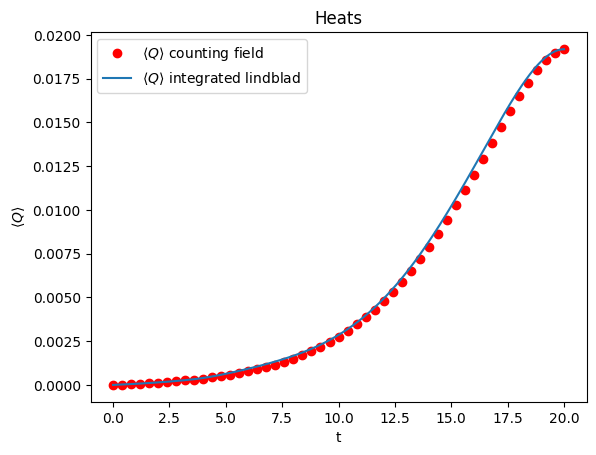

In [9]:
dynamics_cf = compute_dynamics(
    system=system,
    process_tensor=pt_cf,
    initial_state=oqupy.operators.spin_dm("x+"),
    num_steps=num_steps
)
Z0_t=1
Z_t = np.trace(dynamics_cf.states, axis1=1, axis2=2)
Q_t = (np.log(Z_t) - np.log(Z0_t)) / u

#Q_t = np.trace(dynamics_cf.states, axis1=1, axis2=2).imag/ u

plt.plot(np.linspace(0, f_time, num_steps+1), Q_t,'ro',label=r"$\langle Q \rangle$ counting field")
plt.plot(sol_500.t, heat_500,label=r"$\langle Q \rangle$ integrated lindblad")
plt.xlabel("t")
plt.ylabel(r"$\langle Q \rangle$")
plt.title("Heats")
plt.legend()

In [10]:
# now redoing with discretised hamiltonian and gradient calculation
def discrete_hamiltonian(hx,hy,hz):
    return hx*oqupy.operators.sigma("x")+hy*oqupy.operators.sigma("y")+hz*oqupy.operators.sigma("z")

param_sys=oqupy.ParameterizedSystem2ls(discrete_hamiltonian)

param_x = np.linspace(-omega_c/2,0,2*num_steps)

param_y=np.ones(2*num_steps)*0.00000001
param_z=np.ones(2*num_steps)*0.00000001


target_derivative = discrete_hamiltonian(param_x[-1],param_y[-1],param_z[-1]) 

def omega_t_discrete(hx):
    return np.abs(2*hx) + 1e-8

def gammaA_discrete(hx):
    w = omega_t_discrete(hx)
    return 2 * np.pi * J(w) * n(w)

def gammaE_discrete(hx):
    w = omega_t_discrete(hx)
    return 2 * np.pi * J(w) * (n(w) + 1)

pt = SimpleProcessTensor(hilbert_space_dimension=hs_dim, dt=dt)

for k in range(num_steps):
    t = (k) * dt
    rates = [gammaA_discrete(param_x[2*k]), gammaE_discrete(param_x[2*k])] # parameters are over half timesteps

    D = dissipator_only([rplus,rminus], rates, hs_dim)
    E = expm(dt * D) 

    W = np.zeros((1,1,hs_dim*hs_dim, hs_dim*hs_dim), dtype=complex)
    W[0,0,:,:] = E.T # transpose due to tensornetwork conventions ....

    pt.set_mpo_tensor(k, W)
    pt.set_cap_tensor(k, cap)

pt.set_cap_tensor(num_steps, cap)

param_list =np.vstack([param_x,param_y,param_z]).T

pt_grad=  oqupy.state_gradient(
        system=param_sys,
        initial_state=xplus,
        target_derivative=target_derivative,
        process_tensors=[pt],
        parameters=param_list,
        num_steps=num_steps,
        progress_type='silent')

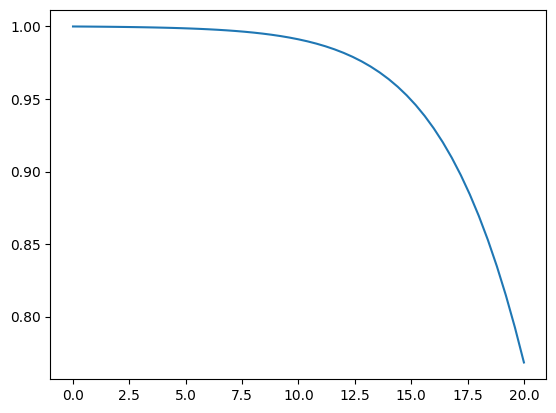

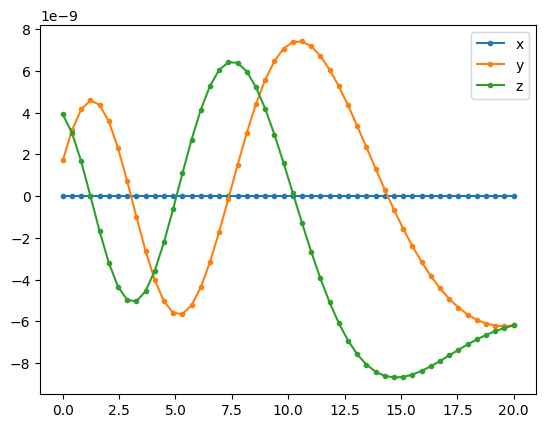

2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.82842712474619
2.8284271247461903
2.8284271247461903
2.82842712474619
2.8284271247461903
2.82842712474619
2.82842712474619
2.82842712474619
2.82842712474619
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.82842712474619
2.82842712474619
2.8284271247461903
2.82842712474619
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.82842712474619
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.82842712474619
2.8284271247461903
2.8284271247461903
2.82842712474619
2.8284271247461903
2.82842712474619
2.8284271247461903
2.82842712474619
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903
2.8284271247461903


In [11]:
grad_sx=[np.trace(r @ sx*2).real for r in pt_grad["dynamics"].states]
plt.plot(np.linspace(0, f_time, num_steps+1), grad_sx)
plt.show()
gps=pt_grad["gradient"]
for i in range(0,gps.shape[0],2): 
    gps[i,:]=gps[i,:]+gps[i+1,:]
gps=gps[0::2]
times=np.linspace(0,f_time,num_steps+1)

plt.plot(np.linspace(0, f_time, num_steps), gps[:,0],label='x',marker='.')
plt.plot(np.linspace(0, f_time, num_steps), gps[:,1],label='y',marker='.')
plt.plot(np.linspace(0, f_time, num_steps), gps[:,2],label='z',marker='.')
plt.legend()
plt.show()

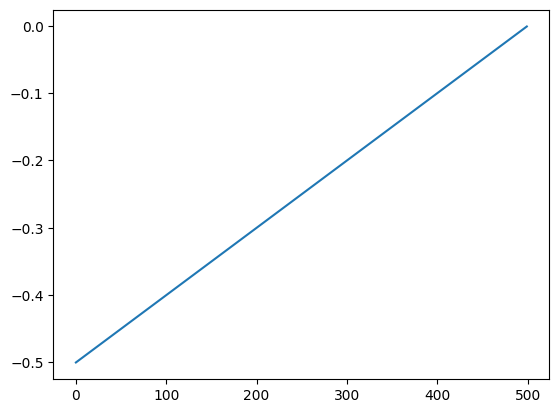

Analytic grad (last hx): 0.007020290980833788
FD grad (last hx):       0.0070201657889623625
Ratio (analytic / FD):   1.000017833178758


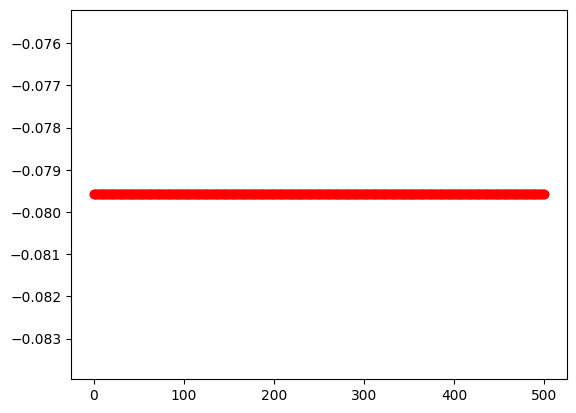

First hx analytic grad: 9.036904e-05, FD grad: 9.198930e-05, Ratio: 0.982386
Middle hx analytic grad: -8.967942e-05, FD grad: -8.904698e-05, Ratio: 1.007102
Last hx analytic grad: 7.020291e-03, FD grad: 7.020166e-03, Ratio: 1.000018


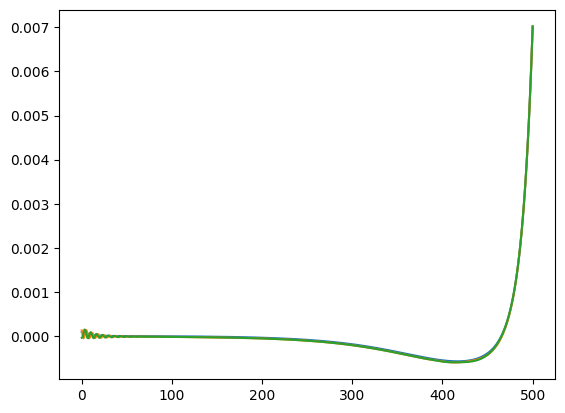

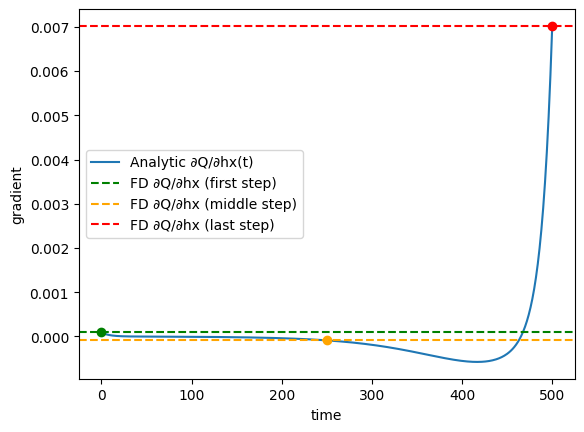

In [12]:
from scipy.optimize import Bounds, minimize, check_grad
from numpy import complex128
from scipy.linalg import expm, expm_frechet
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
f_time = 500
num_steps = 500
dt = f_time / num_steps
T = 0.1309
u = 1e-3

rho0 = op.spin_dm("x+")
num_params = 3
hs_dim = 2

# ----------------------------
# Frequencies and rates
# ----------------------------
def omega_t_discrete(hx):
    #hx = np.clip(hx, -1e-8, None)
    return -2.0 * hx-1e-7  # NO abs, NO sign tricks

def gammaA_discrete(hx):
    w = omega_t_discrete(hx)
    return 2*np.pi * J(w) * n(w)

def gammaE_discrete(hx):
    w = omega_t_discrete(hx)
    return 2*np.pi * J(w) * (n(w) + 1)

# ----------------------------
# Rate derivatives
# ----------------------------
def DgammaA_Dhx(hx):
    w = omega_t_discrete(hx)
    nw = n(w)
    Jw = J(w)
    dJ_dw = 2*alpha*np.exp(-w/omega_c)*(1 - w/omega_c)
    dn_dw = -nw*(1+nw)/T
    return 2*np.pi * (dJ_dw*nw + Jw*dn_dw) * (-2.0)

def DgammaE_Dhx(hx):
    w = omega_t_discrete(hx)
    nw = n(w)
    Jw = J(w)
    dJ_dw = 2*alpha*np.exp(-w/omega_c)*(1 - w/omega_c)
    dn_dw = -nw*(1+nw)/T
    return 2*np.pi * (dJ_dw*(nw+1) + Jw*dn_dw) * (-2.0)

# ----------------------------
# Tilted dissipator
# ----------------------------
def tilted_dissipator(L_ops, rates, omegas, u, dim):
    D = np.zeros((dim*dim, dim*dim), dtype=complex)
    for L, gamma, omega in zip(L_ops, rates, omegas):
        Ld = L.conjugate().T
        D += gamma * np.exp(u*omega) * opr.left_right_super(L, Ld)
        D += -0.5 * gamma * opr.acommutator(Ld @ L)
    return D

def d_tilted_dissipator_dhx(L_ops, gammas, dgammas, omegas, u, dim):
    dD = np.zeros((dim*dim, dim*dim), dtype=complex)

    # dω/dhx is CONSTANT
    domegas = [-2.0, 2.0]

    for L, g, dg, w, dw in zip(L_ops, gammas, dgammas, omegas, domegas):
        Ld = L.conjugate().T
        dD += (dg + u*g*dw) * np.exp(u*w) * opr.left_right_super(L, Ld)
        dD += -0.5 * dg * opr.acommutator(Ld @ L)

    return dD

opt_log=[]
# ----------------------------
# Heat + gradient
# ----------------------------
def heatandgrad_markovian(paras, num_steps):

    reshaped = np.repeat(paras.reshape(-1, num_params), 2, axis=0)

    pt_cf = SimpleProcessTensor(hilbert_space_dimension=2, dt=dt)
    cap = np.array([1.0])
    mpo_derivatives = [None]*num_steps

    for k in range(num_steps):
        hx, hy, hz = reshaped[2*k]

        # CORRECT pairing:
        rates  = [gammaE_discrete(hx), gammaA_discrete(hx)]
        drates = [DgammaE_Dhx(hx),     DgammaA_Dhx(hx)]
        omegas = [ omega_t_discrete(hx), -omega_t_discrete(hx)]
        L_ops  = [rminus, rplus]

        D = tilted_dissipator(L_ops, rates, omegas, u, hs_dim)
        E = expm(dt * D)

        W = np.zeros((1,1,4,4), dtype=complex)
        W[0,0,:,:] = E.T
        pt_cf.set_mpo_tensor(k, W)
        pt_cf.set_cap_tensor(k, cap)

        dD = d_tilted_dissipator_dhx(L_ops, rates, drates, omegas, u, hs_dim)
        dE = expm_frechet(dt*D, dt*dD, compute_expm=False)
        #dE=dD@E*dt

        M = np.zeros((1,1,4,4), dtype=complex)
        M[0,0,:,:] = dE.T
        mpo_derivatives[k] = [M]

    pt_cf.set_cap_tensor(num_steps, cap)

    Z0 = 1.0

    def targ_deriv(rho_f):
        Z = np.trace(rho_f)
        return np.identity(2) / (u * Z)   

    grad_dict = oqupy.state_gradient_env_dependent(
        system=param_sys,
        initial_state=rho0,
        target_derivative=targ_deriv,
        process_tensors=[pt_cf],
        parameters=reshaped,
        mpo_derivatives=mpo_derivatives,
        num_steps=num_steps,
        progress_type="silent"
    )

    states = grad_dict["dynamics"].states
    grads  = grad_dict["gradient"]

    Zt = np.trace(states, axis1=1, axis2=2)
    Qt = (np.log(Zt) - np.log(Z0)) / u

    heat = Qt[-1]
    opt_log.append(heat)
    # combine half steps
    for i in range(0, grads.shape[0], 2):
        grads[i] += grads[i+1]
    grads = grads[0::2]

    return heat, grads.reshape(-1).real


hx0 =np.linspace(-omega_c/2,-0.001, num_steps)
plt.plot(hx0)
plt.show()
#hx0=-np.ones(num_steps)
hy0 = -np.ones(num_steps)*0.00005
hz0 = -np.ones(num_steps)*0.00005

x0 = np.array([v for triple in zip(hx0, hy0, hz0) for v in triple])

bounds = []
for _ in range(num_steps):
    bounds += [(-2, 0), (-0.0005, -0.0001), (-0.0005, -0.0001)]

bounds = Bounds(*zip(*bounds))

def func(z):
    return heatandgrad_markovian(z, num_steps)[0].real

def grad(z):
    return heatandgrad_markovian(z, num_steps)[1].real

#print("Gradient check:", check_grad(func, grad, x0))

h,g= heatandgrad_markovian(x0, num_steps)

eps = 1e-6


last_hx_index = (num_steps - 1) * num_params 

z_plus = x0.copy()
z_minus = x0.copy()

z_plus[last_hx_index] += eps
z_minus[last_hx_index] -= eps

f_plus = func(z_plus)
f_minus = func(z_minus)

grad_last_hx_fd = (f_plus - f_minus) / (2 * eps)

print("Analytic grad (last hx):", g[last_hx_index])
print("FD grad (last hx):      ", grad_last_hx_fd)
print("Ratio (analytic / FD):  ", g[last_hx_index] / grad_last_hx_fd)


plt.plot(np.linspace(0, f_time, num_steps), h* np.ones(num_steps), 'ro', label='heat from counting field')
plt.show()
plt.plot(np.linspace(0, f_time, num_steps), g[::num_params])
plt.plot(np.linspace(0, f_time, num_steps), g[1::num_params])
plt.plot(np.linspace(0, f_time, num_steps), g[2::num_params])

t = np.linspace(0, f_time, num_steps)

hx_grad = g[::num_params]

eps = 1e-6

# Indices of interest
first_hx_index  = 0
middle_hx_index = (num_steps // 2) * num_params
last_hx_index   = (num_steps - 1) * num_params

# Make copies for FD
z_plus = x0.copy()
z_minus = x0.copy()

# Dictionary to store FD values
fd_grads = {}

for idx, name in zip([first_hx_index, middle_hx_index, last_hx_index],
                     ["first", "middle", "last"]):
    z_plus[idx]  = x0[idx] + eps
    z_minus[idx] = x0[idx] - eps

    f_plus  = func(z_plus)
    f_minus = func(z_minus)

    fd_grads[name] = (f_plus - f_minus) / (2*eps)

    # Reset for next iteration
    z_plus[idx] = x0[idx]
    z_minus[idx] = x0[idx]

# Print comparisons
for idx, name in zip([first_hx_index, middle_hx_index, last_hx_index],
                     ["first", "middle", "last"]):
    print(f"{name.capitalize()} hx analytic grad: {g[idx]:.6e}, FD grad: {fd_grads[name]:.6e}, Ratio: {g[idx]/fd_grads[name]:.6f}")

# Plot
t = np.linspace(0, f_time, num_steps)
hx_grad = g[::num_params]

plt.figure()
plt.plot(t, hx_grad, label="Analytic ∂Q/∂hx(t)")
plt.axhline(fd_grads["first"], color="green", linestyle="--", label="FD ∂Q/∂hx (first step)")
plt.axhline(fd_grads["middle"], color="orange", linestyle="--", label="FD ∂Q/∂hx (middle step)")
plt.axhline(fd_grads["last"], color="red", linestyle="--", label="FD ∂Q/∂hx (last step)")
plt.scatter(t[0], hx_grad[0], color="green", zorder=5)
plt.scatter(t[num_steps//2], hx_grad[num_steps//2], color="orange", zorder=5)
plt.scatter(t[-1], hx_grad[-1], color="red", zorder=5)
plt.xlabel("time")
plt.ylabel("gradient")
plt.legend()
plt.show()


plt.show()

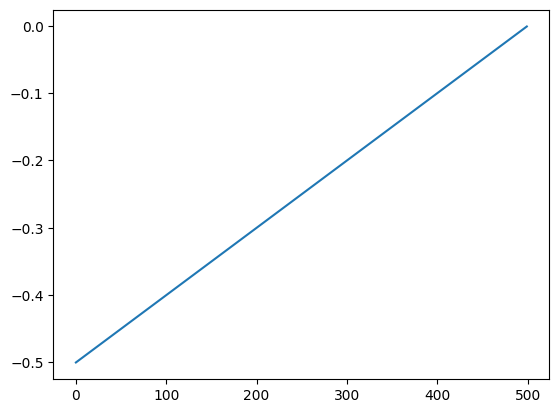

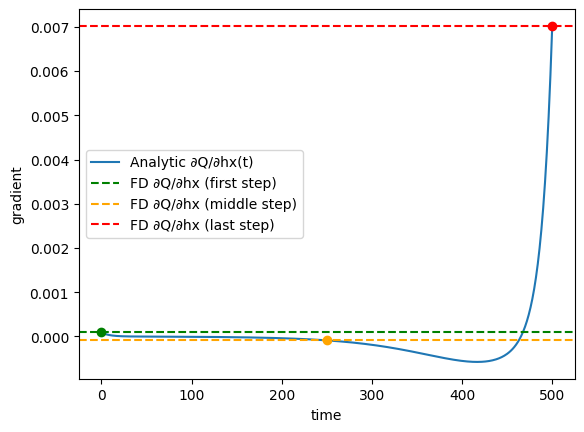

In [19]:
opt_log=[]
def heatandgrad_markovian(paras, num_steps):

    reshaped = np.repeat(paras.reshape(-1, num_params), 2, axis=0)

    # ----------------------------
    # Forward propagation
    # ----------------------------
    rhos = [rho0.copy()]
    Es   = []
    dEs  = []

    for k in range(num_steps):
        hx, hy, hz = reshaped[2*k]

        rates  = [gammaE_discrete(hx), gammaA_discrete(hx)]
        drates = [DgammaE_Dhx(hx),     DgammaA_Dhx(hx)]
        omegas = [ omega_t_discrete(hx), -omega_t_discrete(hx)]
        L_ops  = [rminus, rplus]

        D  = tilted_dissipator(L_ops, rates, omegas, u, hs_dim)
        dD = d_tilted_dissipator_dhx(L_ops, rates, drates, omegas, u, hs_dim)

        E  = expm(dt * D)
        dE = expm_frechet(dt * D, dt * dD, compute_expm=False)

        Es.append(E)
        dEs.append(dE)

        rho_vec = E @ rhos[-1].reshape(-1)
        rhos.append(rho_vec.reshape(hs_dim, hs_dim))

    # ----------------------------
    # Heat from counting field
    # ----------------------------
    Zt = np.array([np.trace(rho) for rho in rhos])
    Qt = (np.log(Zt) - np.log(Zt[0])) / u
    heat = Qt[-1].real
    opt_log.append(heat)

    # ----------------------------
    # Backward propagation (adjoint)
    # ----------------------------
    lambdas = [None] * (num_steps + 1)

    Zf = Zt[-1]
    lambdas[-1] = np.identity(hs_dim) / (u * Zf)

    for k in reversed(range(num_steps)):
        Ek = Es[k]
        lam_vec = lambdas[k+1].reshape(-1)
        lam_prev = Ek.conj().T @ lam_vec
        lambdas[k] = lam_prev.reshape(hs_dim, hs_dim)

    # ----------------------------
    # Gradient assembly
    # ----------------------------
    grads = np.zeros((num_steps, num_params))

    for k in range(num_steps):
        rho_k = rhos[k]
        lam_kp1 = lambdas[k+1]

        dE = dEs[k]

        contrib = np.trace(
            lam_kp1.conj().T @
            (dE @ rho_k.reshape(-1)).reshape(hs_dim, hs_dim)
        )

        grads[k, 0] = contrib.real   # hx
        grads[k, 1] = 0.0            # hy (unused)
        grads[k, 2] = 0.0            # hz (unused)

    # Combine half-steps (same as before)
    grads = grads.reshape(-1)

    return heat, grads.real

hx0 =np.linspace(-omega_c/2,-0.001, num_steps)
plt.plot(hx0)
plt.show()
#hx0=-np.ones(num_steps)
hy0 = -np.ones(num_steps)*0.00005
hz0 = -np.ones(num_steps)*0.00005

plt.figure()
plt.plot(t, hx_grad, label="Analytic ∂Q/∂hx(t)")
plt.axhline(fd_grads["first"], color="green", linestyle="--", label="FD ∂Q/∂hx (first step)")
plt.axhline(fd_grads["middle"], color="orange", linestyle="--", label="FD ∂Q/∂hx (middle step)")
plt.axhline(fd_grads["last"], color="red", linestyle="--", label="FD ∂Q/∂hx (last step)")
plt.scatter(t[0], hx_grad[0], color="green", zorder=5)
plt.scatter(t[num_steps//2], hx_grad[num_steps//2], color="orange", zorder=5)
plt.scatter(t[-1], hx_grad[-1], color="red", zorder=5)
plt.xlabel("time")
plt.ylabel("gradient")
plt.legend()
plt.show()

Optimization success: True
Maximum absorbed heat Q = -0.08411925404768238
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
0
-0.08411925404768238
[-2.34163144e-06  0.00000000e+00  0.00000000e+00 ...  4.27125061e-06
  0.00000000e+00  0.00000000e+00]


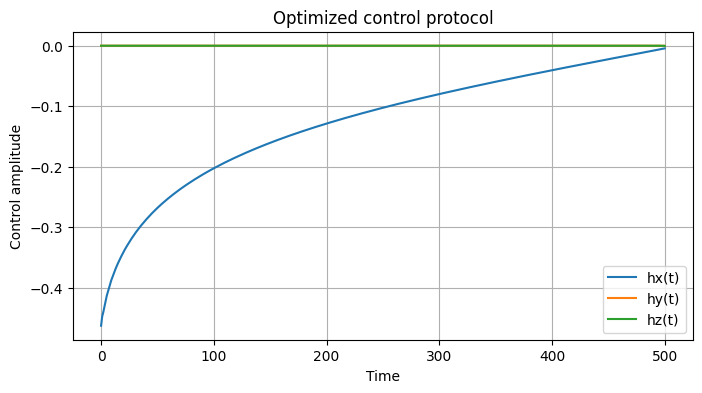

[3.34361433e-05 8.17542606e-05 1.34753520e-04 1.96014306e-04
 2.67707121e-04 3.47036723e-04 4.31835393e-04 5.22791382e-04
 6.20939503e-04 7.25060211e-04 8.32751397e-04 9.43859582e-04
 1.06007096e-03 1.18181489e-03 1.30764278e-03 1.43619398e-03
 1.56762131e-03 1.70255270e-03 1.84074151e-03 1.98166495e-03
 2.12545983e-03 2.27238816e-03 2.42194433e-03 2.57328023e-03
 2.72640717e-03 2.88202022e-03 3.04027958e-03 3.20065620e-03
 3.36286991e-03 3.52720461e-03 3.69379571e-03 3.86223796e-03
 4.03221466e-03 4.20390917e-03 4.37741686e-03 4.55223863e-03
 4.72786819e-03 4.90457390e-03 5.08303126e-03 5.26337399e-03
 5.44504930e-03 5.62760823e-03 5.81129571e-03 5.99660670e-03
 6.18350293e-03 6.37149237e-03 6.56038348e-03 6.75042807e-03
 6.94173193e-03 7.13403574e-03 7.32711415e-03 7.52101415e-03
 7.71578969e-03 7.91126949e-03 8.10732382e-03 8.30418660e-03
 8.50217164e-03 8.70112428e-03 8.90053600e-03 9.10026800e-03
 9.30077220e-03 9.50238381e-03 9.70476888e-03 9.90743760e-03
 1.01104328e-02 1.031409

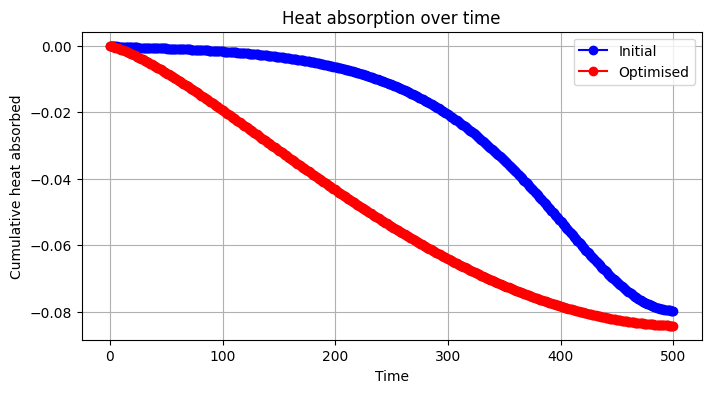

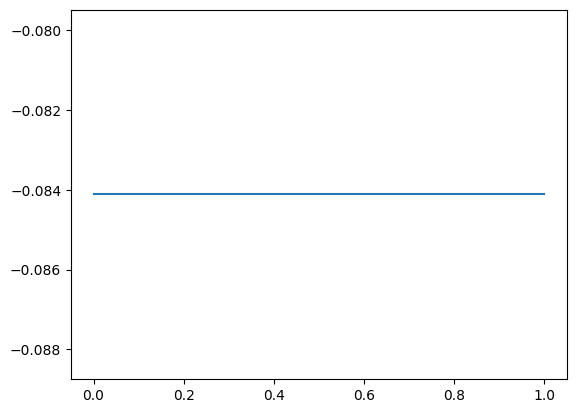

In [20]:
from scipy.optimize import Bounds, minimize

hx0 =np.linspace(-omega_c/2, -0.001, num_steps)
hy0 = -np.ones(num_steps) * 0.00005
hz0 = -np.ones(num_steps) * 0.00005

x0 = np.array([v for triple in zip(hx0, hy0, hz0) for v in triple])

bounds_list = []
for _ in range(num_steps):
    bounds_list += [(-2, 0), (-0.0005, -0.0001), (-0.0005, -0.0001)]
bounds = Bounds(*zip(*bounds_list))

# ----------------------------
# Objective for minimize (return both value and gradient)
# ----------------------------
def obj_with_grad(z):
    heat, grad = heatandgrad_markovian(z, num_steps)
    # We want to maximize heat absorption -> minimize -heat
    return heat.real, grad.real

res = minimize(
    fun=obj_with_grad,
    x0=x_opt,
    jac=True,             
    bounds=bounds,
    method="L-BFGS-B",
    options={"disp": True, "maxiter": 2000}
)

x_opt = res.x
hx_opt = x_opt[::3]
hy_opt = x_opt[1::3]
hz_opt = x_opt[2::3]

# Compute heat over time using optimal controls
heat_opt, _ = heatandgrad_markovian(x_opt, num_steps)

print("Optimization success:", res.success)
print("Maximum absorbed heat Q =", heat_opt)
print(res.message)      # description of why L-BFGS-B stopped
print(res.nit)          # number of iterations used
print(res.fun)          # final objective value
print(res.jac)          # final gradient



t = np.linspace(0, f_time, num_steps)

plt.figure(figsize=(8,4))
plt.plot(t, hx_opt, label="hx(t)")
plt.plot(t, hy_opt, label="hy(t)")
plt.plot(t, hz_opt, label="hz(t)")
plt.xlabel("Time")
plt.ylabel("Control amplitude")
plt.title("Optimized control protocol")
plt.legend()
plt.grid(True)
plt.show()

def heat_over_time(x):
    reshaped = np.repeat(x.reshape(-1, num_params), 2, axis=0)
    Q_t = []
    Z0 = 1.0
    for k in range(num_steps):
        hx, hy, hz = reshaped[2*k]
        rates = [gammaE_discrete(hx), gammaA_discrete(hx)]
        omegas = [omega_t_discrete(hx), -omega_t_discrete(hx)]
        L_ops = [rminus, rplus]
        D = tilted_dissipator(L_ops, rates, omegas, u, hs_dim)
        E = expm(dt*D)
        if k == 0:
            rho = rho0.copy()
        rho = E @ rho.flatten()
        Z = np.trace(rho.reshape(2,2))
        Qt = (np.log(Z) - np.log(Z0))/u
        Q_t.append(Qt.real)
    return np.array(Q_t)


Q_t = heat_over_time(x0)
Q_t_opt = heat_over_time(x_opt)

print(Q_t-Q_t_opt) # check with finite time limits of landauer

plt.figure(figsize=(8,4))
plt.plot(t, Q_t, 'b-o', label="Initial")
plt.plot(t, Q_t_opt, 'r-o', label="Optimised")
plt.xlabel("Time")
plt.ylabel("Cumulative heat absorbed")
plt.title("Heat absorption over time")
plt.grid(True)
plt.legend()
plt.show()

plt.plot(opt_log)
plt.show()

500
(500, 3)
[-9.99999945e-01 -2.51770527e-04 -2.16222532e-04] [-0.9946769  -0.05880656 -0.08461479]
[0.46248649 0.4470887  0.43976876 0.43070595 0.42102076 0.4131845
 0.40664615 0.40012123 0.3934874  0.38751814 0.38252287 0.37776272
 0.37270385 0.3676906  0.36318324 0.35913443 0.35518274 0.35121684
 0.3474104  0.34380924 0.34028079 0.33679613 0.33348331 0.3303944
 0.32738559 0.32434467 0.32134704 0.31848959 0.31573464 0.31300179
 0.31030684 0.30771666 0.30521864 0.30274971 0.30031719 0.29798764
 0.2957615  0.29355244 0.29131305 0.28909612 0.28697058 0.28492664
 0.28289576 0.28085109 0.27883984 0.27690324 0.2750147  0.27313409
 0.27127197 0.26945831 0.26769031 0.2659452  0.2642212  0.26253522
 0.26088378 0.25923822 0.2575906  0.25597418 0.25441516 0.25288792
 0.2513497  0.24980623 0.24830239 0.24684974 0.2454134  0.24397263
 0.24254764 0.24115673 0.23977949 0.2383918  0.23701217 0.23567611
 0.23437902 0.23307972 0.23176473 0.23047057 0.22922447 0.2280002
 0.22675495 0.22549105 0.224250

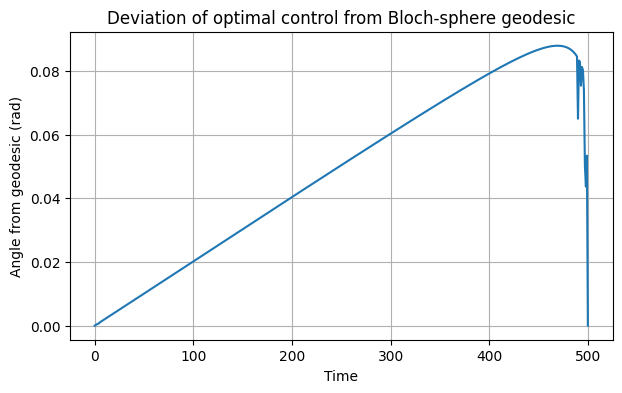

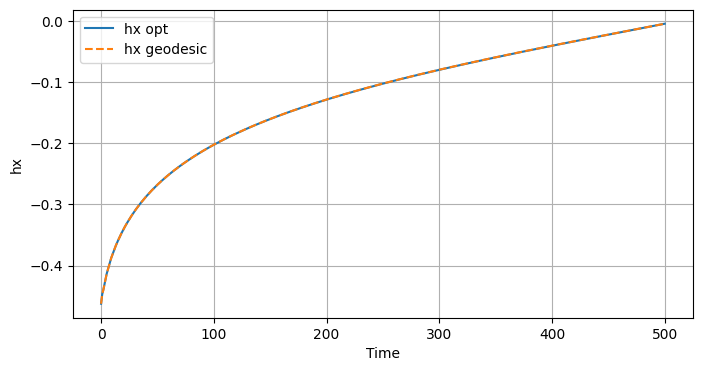

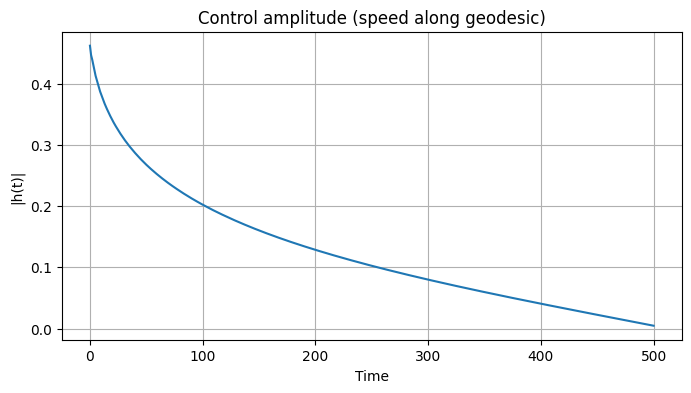

In [26]:

# ---------- Helpers ----------
def normalize_controls(hx, hy, hz, eps=1e-12):
    h = np.vstack([hx, hy, hz]).T
    norms = np.linalg.norm(h, axis=1, keepdims=True)
    norms = np.maximum(norms, eps)
    return h / norms, norms[:, 0]

def bloch_geodesic(h0, h1, s):
    dot = np.clip(np.dot(h0, h1), -1.0, 1.0)
    theta = np.arccos(dot)
    if theta < 1e-10:
        return np.outer(np.ones_like(s), h0)
    sin_theta = np.sin(theta)
    return (
        np.sin((1 - s) * theta)[:, None] / sin_theta * h0 +
        np.sin(s * theta)[:, None] / sin_theta * h1
    )

def geodesic_deviation(h_actual, h_geo):
    dots = np.sum(h_actual * h_geo, axis=1)
    dots = np.clip(dots, -1.0, 1.0)
    return np.arccos(dots)

# ---------- Extract optimized controls ----------
hx = hx_opt.copy()
hy = hy_opt.copy()
hz = hz_opt.copy()

t = np.linspace(0, f_time, num_steps)
s = np.linspace(0, 1, num_steps)
h_dir, h_norm = normalize_controls(hx, hy, hz)

h_geo = bloch_geodesic(h_dir[0], h_dir[-1], s)

deviation = geodesic_deviation(h_dir, h_geo)
print(h_geo.shape)
print(h_dir[0], h_geo[-1])
print(h_norm)
hx_geo = h_norm * h_geo[:, 0]
hy_geo = h_norm * h_geo[:, 1]
hz_geo = h_norm * h_geo[:, 2]


plt.figure(figsize=(7,4))
plt.plot(t, deviation)
plt.xlabel("Time")
plt.ylabel("Angle from geodesic (rad)")
plt.title("Deviation of optimal control from Bloch-sphere geodesic")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(t, hx, label="hx opt")
plt.plot(t, hx_geo, "--", label="hx geodesic")
plt.xlabel("Time")
plt.ylabel("hx")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(t, h_norm)
plt.xlabel("Time")
plt.ylabel("|h(t)|")
plt.title("Control amplitude (speed along geodesic)")
plt.grid(True)
plt.show()


ValueError: x and y must have same first dimension, but have shapes (50,) and (500,)

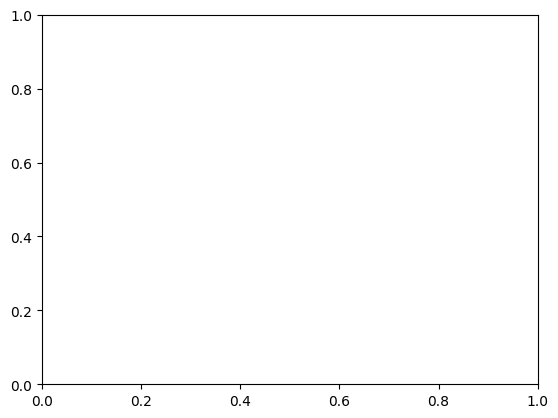

In [27]:
plt.plot(times[:-1],hx,label='exact')
plt.plot(sol_500.t,-0.5*omega_t(sol_500.t,1/500),label='lindblad')
plt.xlabel('t')
plt.ylabel('hx')
plt.legend()
plt.show()

plt.plot(times,tti_sx,label='exact')
plt.plot(sol_500.t,sx_500,label='lindblad')
plt.xlabel('t')
plt.ylabel('<sigma_x>')
plt.legend()
plt.show()

plt.plot(times,tti_heats,label='exact')
plt.plot(sol_500.t,-heat_500,label='lindblad')
plt.xlabel('t')
plt.ylabel('Q')
plt.legend()
plt.show()


dict_keys(['result', 'log', 'fidelitygrad', 'opttime', 'parameters', 'bounds', 'gtol'])


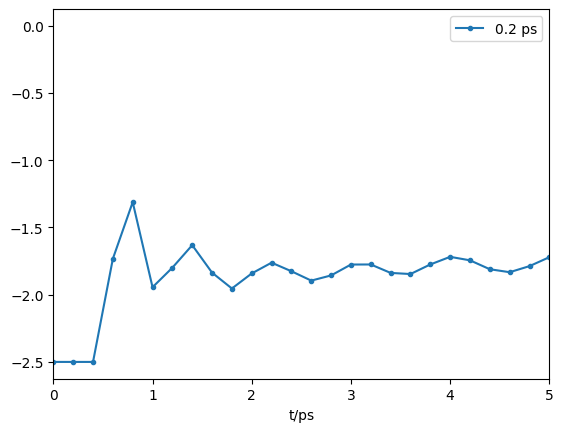

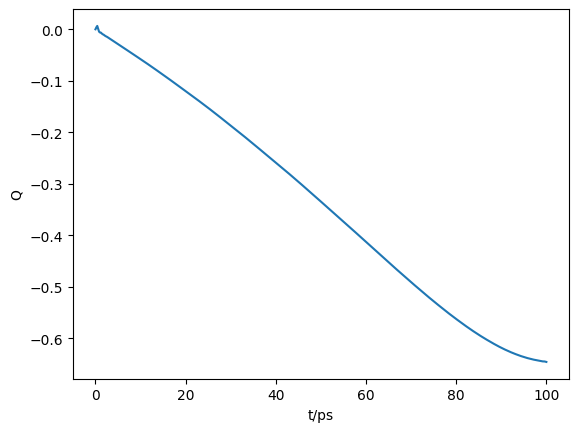

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


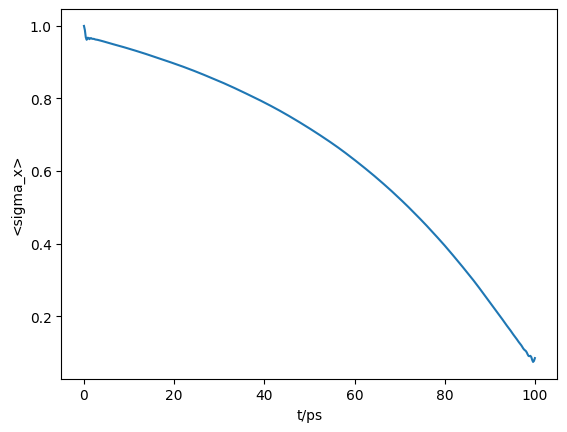

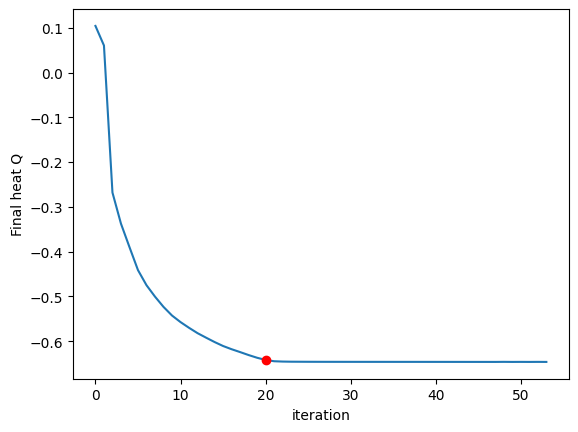

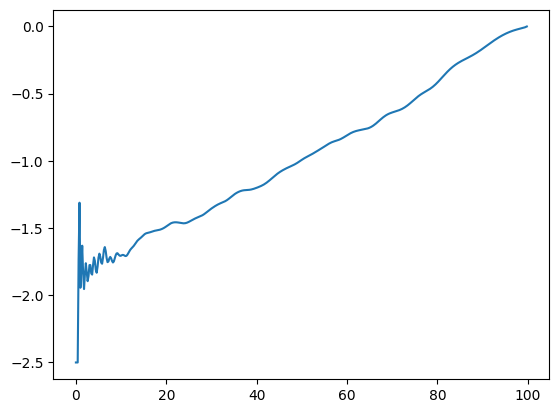

In [ ]:
import dill
import matplotlib.pyplot as plt
import numpy as np
import oqupy.operators as op
# higher temp 
for dt in [0.2]:
    with open('results/zero_control_10K/conv_checks/dt={0}_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0/100ps'.format(dt), 'rb') as f:
        opt_dict = dill.load(f)
    print(opt_dict.keys())

    hx = opt_dict['result'].x[0::3]
    #hy = opt_dict['result'].x[1::3]
    #hz = opt_dict['result'].x[2::3]
    hx = opt_dict['log'][20]['x'][:,0::3][0::2]

    t_prot = 100
    num_steps = len(hx)
    times=np.linspace(0,t_prot,num_steps+1)
    tti_heats=opt_dict['log'][-1]['full heats']
    dynamics=opt_dict['fidelitygrad']['dynamics']

    plt.plot(times[:-1],hx,label='{0} ps'.format(dt),marker='.')
    #plt.plot(times[:-1],hy,label='hy')
    #plt.plot(times[:-1],hz,label='hz')
plt.xlim(0,5)
plt.xlabel('t/ps')
plt.legend()
plt.show()

plt.plot(times,tti_heats)
#plt.xlim(0,50)
plt.xlabel('t/ps')
plt.ylabel('Q')
plt.show()
tti_sx=[np.trace(states@op.sigma("x")) for states in dynamics.states]
plt.plot(times,tti_sx)
plt.xlabel('t/ps')
plt.ylabel('<sigma_x>')
plt.show()

current_iteration=20
num_its=np.shape(opt_dict['log'])[0]
fin_heats=[entry['full heats'][-1] for entry in opt_dict['log']]
plt.plot(range(num_its),fin_heats)
plt.plot(current_iteration,fin_heats[current_iteration],'ro')
plt.xlabel('iteration')
plt.ylabel('Final heat Q')
plt.show()


plt.plot(times[:-1],hx)
plt.show()

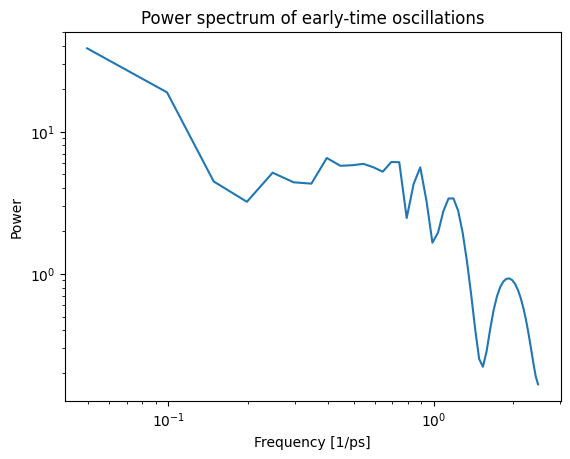

In [ ]:
# --- Parameters for analysis ---
t_osc_max = 20.0      # ps, where you think oscillations live
t_decay_min = 20.0  # ps, where smooth decay begins

dt_time = times[1] - times[0]

# Early-time (oscillatory) region
mask_osc = times[:-1] <= t_osc_max
hx_osc = hx[mask_osc]
t_osc = times[:-1][mask_osc]

# Late-time (decay) region
mask_decay = times[:-1] >= t_decay_min
hx_decay = hx[mask_decay]
t_decay = times[:-1][mask_decay]

# --- FFT / Power spectrum ---
# Flatten the array to 1D
hx_osc_1d = np.asarray(hx_osc).squeeze()  # shape now (26,)

hx_osc_demeaned = hx_osc_1d - np.mean(hx_osc_1d)

fft_vals = np.fft.rfft(hx_osc_demeaned)
freqs = np.fft.rfftfreq(len(hx_osc_demeaned), d=dt_time)

power = np.abs(fft_vals)**2

plt.figure()
plt.loglog(freqs[1:], power[1:])  # skip zero frequency
plt.xlabel('Frequency [1/ps]')
plt.ylabel('Power')
plt.title('Power spectrum of early-time oscillations')
plt.show()



In [ ]:

T = 10*0.131
initial_omega=5

def omega_t(t, omega0):
    return initial_omega*(1 - omega0 * t) + 1e-8 # to match control

def n(omega):
    return 1 / (np.exp(omega / (T)) - 1)

def gammaA(t, omega0):
    w = omega_t(t, omega0)
    return 2 * np.pi * J(w) * n(w)

def gammaE(t, omega0):
    w = omega_t(t, omega0)
    return 2 * np.pi * J(w) * (n(w) + 1)

# Lindblad RHS
def lindblad_rhs(t, rho_flat, omega0):
    rho = rho_flat.reshape(2, 2)
    drho = (-0.5 * gammaA(t, omega0) * (rminus @ rplus @ rho + rho @ rminus @ rplus - 2 * rplus @ rho @ rminus)
            -0.5 * gammaE(t, omega0) * (rplus @ rminus @ rho + rho @ rplus @ rminus - 2 * rminus @ rho @ rplus)
            -1j * (Hdot(t, omega0) @ rho - rho @ Hdot(t, omega0)))
    return drho.flatten()

# now for comparison with tempo

sol_100 = solve_ivp(lindblad_rhs, [0, 100], xplus.flatten(), args=(1/100,), t_eval=np.linspace(0, 100, 5000)) 
rho_t = sol_100.y.T.reshape(-1, 2, 2)
sx_100 = [np.trace(r @ sx*2).real for r in rho_t]

# heat comparison
drho_dt = np.gradient(rho_t, axis=0) / np.gradient(sol_100.t)[:, None, None]
omega0 = 1/100
instant_heat = [-np.trace(d @ sx * omega_t(t, omega0)).real for d, t in zip(drho_dt, sol_100.t)]

# cumulative heat at each time step
heat_100 = np.cumsum(instant_heat * np.gradient(sol_100.t))



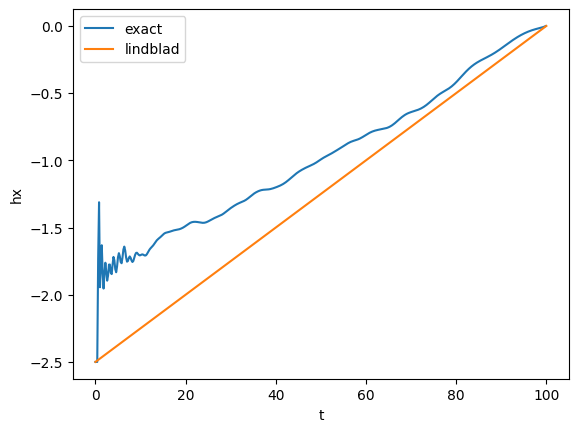

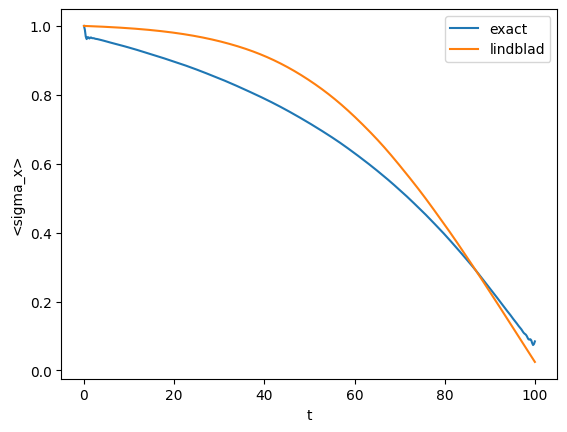

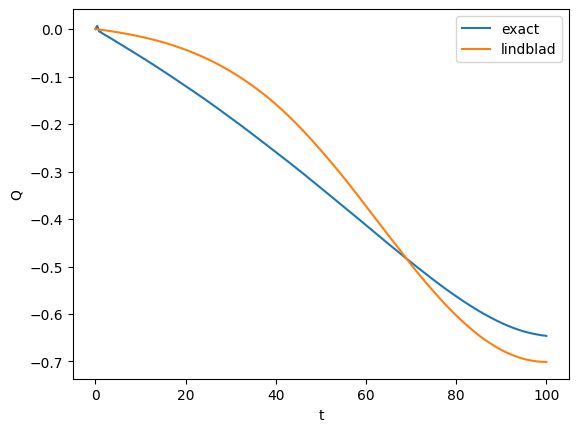

In [ ]:
plt.plot(times[:-1],hx,label='exact')
plt.plot(sol_100.t,-0.5*omega_t(sol_100.t,1/100),label='lindblad')
plt.xlabel('t')
plt.ylabel('hx')
plt.legend()
plt.show()

plt.plot(times,tti_sx,label='exact')
plt.plot(sol_100.t,sx_100,label='lindblad')
plt.xlabel('t')
plt.ylabel('<sigma_x>')
plt.legend()
plt.show()

plt.plot(times,tti_heats,label='exact')
plt.plot(sol_100.t,-heat_100,label='lindblad')
plt.xlabel('t')
plt.ylabel('Q')
plt.legend()
plt.show()


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


Optimised cost: 0.37994872188058887


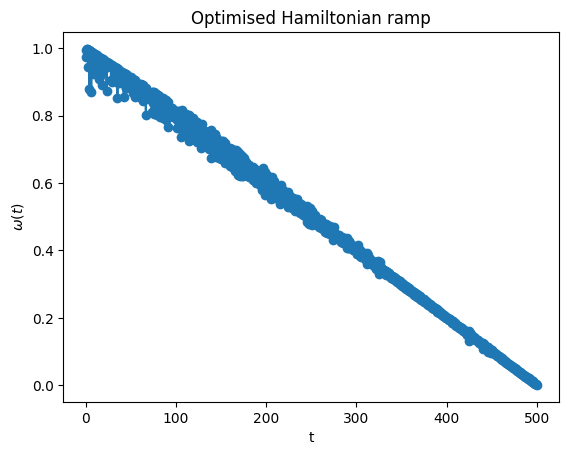

In [ ]:
from scipy.optimize import minimize
from scipy.linalg import sqrtm
# --- Control discretisation ---
N = 1000
tmax = 500.0
ts = np.linspace(0, tmax, N+1)

def omega_t(t, omegas):
    k = min(int(t / tmax * N), N-1)
    return max(omegas[k], 1e-6)

def Hdot(t, omegas):
    return -omega_t(t, omegas) * sx

# --- Lindblad equation ---
def lindblad_rhs(t, rho_flat, omegas):
    rho = rho_flat.reshape(2, 2)
    w = omega_t(t, omegas)

    gA = 2*np.pi*J(w)*n(w)
    gE = 2*np.pi*J(w)*(n(w)+1)

    drho = (
        -0.5*gA*(rminus@rplus@rho + rho@rminus@rplus - 2*rplus@rho@rminus)
        -0.5*gE*(rplus@rminus@rho + rho@rplus@rminus - 2*rminus@rho@rplus)
        -1j*(Hdot(t, omegas)@rho - rho@Hdot(t, omegas))
    )
    return drho.flatten()

# --- Heat functional ---
def total_heat(sol, omegas):
    rho_t = sol.y.T.reshape(-1, 2, 2)
    drho_dt = np.gradient(rho_t, axis=0) / np.gradient(sol.t)[:,None,None]

    integrand = [
        -np.trace(d @ sx * omega_t(t, omegas)).real
        for d, t in zip(drho_dt, sol.t)
    ]
    return np.trapz(integrand, sol.t)

# --- Cost function ---
lam = 1e-2

maxmixed=np.array([[0.5,0],[0,0.5]])

def cost(omegas):
    sol = solve_ivp(
        lindblad_rhs,
        [0, tmax],
        xplus.flatten(),
        args=(omegas,),
        t_eval=np.linspace(0, tmax, 10),
        rtol=1e-7
    )

    rho_f = sol.y[:, -1].reshape(2, 2)
    evals = np.linalg.eigvalsh(rho_f)
    #entropy = -np.sum(evals * np.log(evals + 1e-12))
    #fidelity= np.trace(np.sqrt(sqrtm(maxmixed) @ rho_f @ sqrtm(maxmixed)))**2

    Q = total_heat(sol, omegas)

    def smoothness_penalty(omegas):
        return np.sum(np.diff(omegas)**2)

    return Q 


# --- Optimisation ---
omegas0 = np.linspace(1,0.001, N)
bounds = [(1e-3, 1.0) for _ in range(N)]

res = minimize(
    cost,
    omegas0,
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 50}
)

omegas_opt = res.x
print("Optimised cost:", cost(omegas_opt))

# --- Plot optimal protocol ---
plt.plot(np.linspace(0, tmax, N), omegas_opt, 'o-')
plt.xlabel("t")
plt.ylabel(r"$\omega(t)$")
plt.title("Optimised Hamiltonian ramp")
plt.show()


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


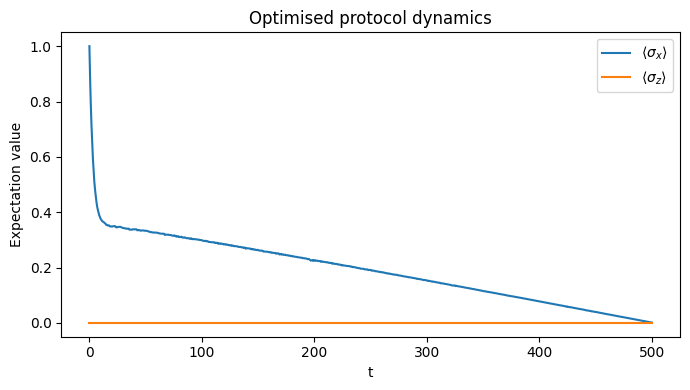

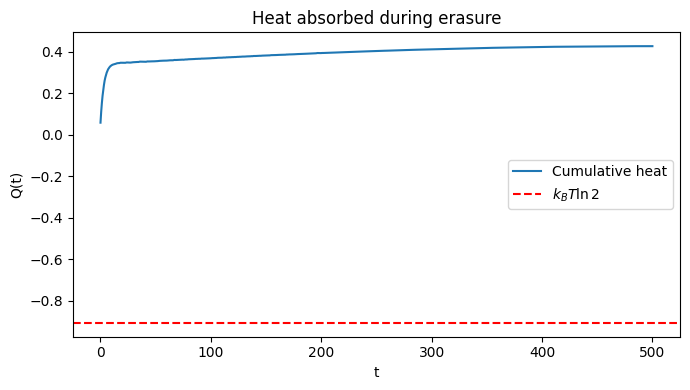

In [ ]:
# --- Solve dynamics with optimised protocol ---
t_eval = np.linspace(0, tmax, 800)

sol_opt = solve_ivp(
    lindblad_rhs,
    [0, tmax],
    xplus.flatten(),
    args=(omegas_opt,),
    t_eval=t_eval,
    rtol=1e-7
)

rho_t = sol_opt.y.T.reshape(-1, 2, 2)

# --- Expectation values ---
sx_exp = [np.trace(r @ (2*sx)).real for r in rho_t]
sz_exp = [np.trace(r @ (2*sz)).real for r in rho_t]

# --- Heat current and cumulative heat ---
drho_dt = np.gradient(rho_t, axis=0) / np.gradient(sol_opt.t)[:,None,None]

heat_current = np.array([
    -np.trace(d @ sx * omega_t(t, omegas_opt)).real
    for d, t in zip(drho_dt, sol_opt.t)
])

cumulative_heat = np.cumsum(
    heat_current * np.gradient(sol_opt.t)
)

# --- Plot dynamics ---
plt.figure(figsize=(7,4))
plt.plot(sol_opt.t, sx_exp, label=r"$\langle\sigma_x\rangle$")
plt.plot(sol_opt.t, sz_exp, label=r"$\langle\sigma_z\rangle$")
plt.xlabel("t")
plt.ylabel("Expectation value")
plt.title("Optimised protocol dynamics")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot heat ---
plt.figure(figsize=(7,4))
plt.plot(sol_opt.t, cumulative_heat, label="Cumulative heat")
plt.axhline(-0.1309*T*np.log(2), color="r", linestyle="--", label=r"$k_BT\ln 2$")
plt.xlabel("t")
plt.ylabel("Q(t)")
plt.title("Heat absorbed during erasure")
plt.legend()
plt.tight_layout()
plt.show()
